# Satellite Altimetry

## Load Libraries

In [6]:
import sys
from pathlib import Path

# Make sure the project root (Codes/) is importable so we can `import config.*`
_root = Path.cwd()
if not (_root / "config").is_dir() and (_root.parent / "config").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap

from config.eez import getEEZ
from config.regions import resolve_region_settings
from config.spatial import subset_to_bbox

## User Input

In [7]:
# -------------------------
# USER CONFIG (pick one)
# -------------------------
REGION = "NIU"  # options: "PACIFIC", "NRU", "NIU"

# FOOTER TEXT
TEXT_LEFT = "Nauru Meteorological Service (NMS) 2026"
TEXT_RIGHT = "Copernicus"
PLOT_TITLE = "Satellite Sea Level Trends (1982–2024) — Nauru"

# Pull bbox + EEZ layer path from the shared config package
bbox, eez_zip_path = resolve_region_settings(REGION)

## Read NetCDF

In [8]:
# -------------------------
# Read NetCDF
# -------------------------
ds = Dataset("https://ocean-thredds01.spc.int/thredds/dodsC/POP/PCC/satellite_sea_level_trends.nc", "r")
sl = ds.variables["trends"][:]
lat = ds.variables["lat"][:]
lon = ds.variables["lon"][:]


## Extract Data

In [9]:
# Replace fill values with masked values
fill_value = getattr(ds.variables["trends"], "_FillValue", None)
if fill_value is not None:
    sl = np.ma.masked_where(sl == fill_value, sl)

# Convert longitude from 0-360 to -180..180
lon = np.where(lon > 180, lon - 360, lon)

# Sort longitudes and reorder sst accordingly
lon_sort = np.argsort(lon)
lon = lon[lon_sort]
sl = sl[:, lon_sort]

# Wrap lon to 0..360 for plotting/subsetting in Pacific-centered convention
lon_wrapped = np.where(lon < 0, lon + 360, lon)

# Sort wrapped longitudes and reorder sst accordingly
wrap_sort = np.argsort(lon_wrapped)
lon_wrapped = lon_wrapped[wrap_sort]
sl = sl[:, wrap_sort]

# Subset to selected bbox (PACIFIC keeps original big domain)
lon2d, lat2d, sst_sub = subset_to_bbox(lat, lon_wrapped, sl, bbox)

# Use the actual data grid extent for plotting so the filled field reaches the axes
plot_bbox = dict(
    west=float(np.nanmin(lon2d)),
    east=float(np.nanmax(lon2d)),
    south=float(np.nanmin(lat2d)),
    north=float(np.nanmax(lat2d)),
)

# Levels / colormap
levels = np.arange(0, 8, 0.05)
cmap = plt.get_cmap("RdBu_r")
norm = BoundaryNorm(levels, cmap.N)


## Plot

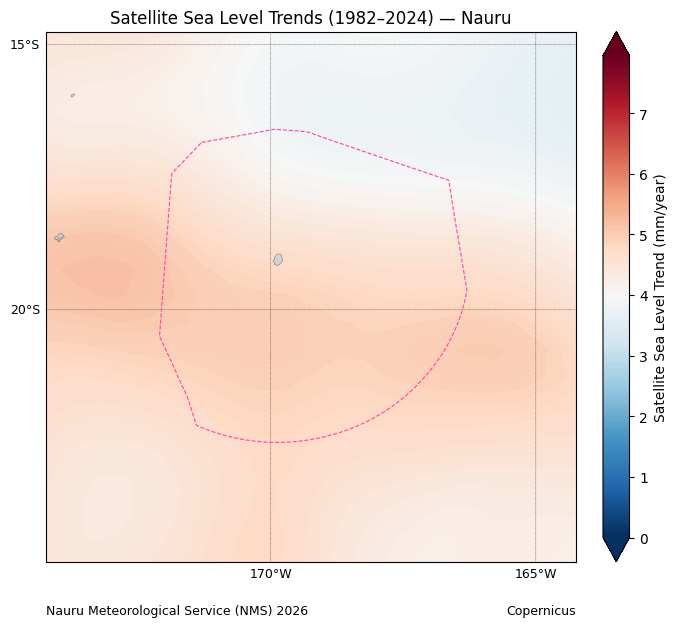

In [10]:

# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

m = Basemap(
    projection="cyl",
    llcrnrlon=plot_bbox["west"],
    urcrnrlon=plot_bbox["east"],
    llcrnrlat=plot_bbox["south"],
    urcrnrlat=plot_bbox["north"],
    resolution="h",
    ax=ax,
)

cf = m.contourf(
    lon2d, lat2d, sst_sub,
    levels=levels, cmap=cmap, norm=norm,
    extend="both", latlon=True
)

# Ensure the axes match the map/data extent (no extra margins)
ax.set_xlim(plot_bbox["west"], plot_bbox["east"])
ax.set_ylim(plot_bbox["south"], plot_bbox["north"])
ax.margins(x=0, y=0)

m.drawcoastlines(color="grey", linewidth=0.8)
m.fillcontinents(color="lightgrey", lake_color="white", zorder=10)

# Gridlines: PACIFIC uses your original spacing; country zoom uses finer spacing
if REGION == "PACIFIC":
    par_step = 15
    mer_step = 30
else:
    par_step = 5
    mer_step = 5

par_start = np.floor(plot_bbox["south"] / par_step) * par_step
par_end   = np.ceil(plot_bbox["north"] / par_step) * par_step
mer_start = np.floor(plot_bbox["west"] / mer_step) * mer_step
mer_end   = np.ceil(plot_bbox["east"] / mer_step) * mer_step

m.drawparallels(np.arange(par_start, par_end + 0.1, par_step),
                labels=[1, 0, 0, 0], fontsize=9, linewidth=0.3, dashes=[1, 1])
m.drawmeridians(np.arange(mer_start, mer_end + 0.1, mer_step),
                labels=[0, 0, 0, 1], fontsize=9, linewidth=0.3, dashes=[1, 1])

# Colorbar: keep smooth shading but reduce tick density
cb_ticks = np.arange(levels[0], levels[-1] + 1e-6, 1.0)
cbar = plt.colorbar(cf, pad=0.02, ticks=cb_ticks)
cbar.ax.minorticks_off()
cbar.set_label("Satellite Sea Level Trend (mm/year)")
plt.title(PLOT_TITLE)

# EEZ on top (last)
getEEZ(ax=ax, m=m, local_path=eez_zip_path, color="#FF46A2", linewidth=0.8, linestyle="--")

plt.tight_layout()

# Put footer relative to the axes (tracks bbox/plot size)
ax.text(0.0, -0.08, TEXT_LEFT,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, color="black", clip_on=False)

ax.text(1.0, -0.08, TEXT_RIGHT,
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="black", clip_on=False)
plt.show()

ds.close()